<a href="https://colab.research.google.com/github/nightshadeX16/My-Colab-ML-Projects/blob/main/Temperature_Forecasting_Using_an_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Install and Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from scipy import stats

**Download and Explore Dataset**

In [ ]:
# Download the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)

# Rename columns to match the code requirements
df.columns = ['timestamp', 'value']

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))
print("\nLast 10 rows:")
print(df.tail(10))
print("\nDataset Statistics:")
print(df['value'].describe())

Dataset Shape: (3650, 2)

First 10 rows:
    timestamp  value
0  1981-01-01   20.7
1  1981-01-02   17.9
2  1981-01-03   18.8
3  1981-01-04   14.6
4  1981-01-05   15.8
5  1981-01-06   15.8
6  1981-01-07   15.8
7  1981-01-08   17.4
8  1981-01-09   21.8
9  1981-01-10   20.0

Last 10 rows:
       timestamp  value
3640  1990-12-22   13.2
3641  1990-12-23   13.9
3642  1990-12-24   10.0
3643  1990-12-25   12.9
3644  1990-12-26   14.6
3645  1990-12-27   14.0
3646  1990-12-28   13.6
3647  1990-12-29   13.5
3648  1990-12-30   15.7
3649  1990-12-31   13.0

Dataset Statistics:
count    3650.000000
mean       11.177753
std         4.071837
min         0.000000
25%         8.300000
50%        11.000000
75%        14.000000
max        26.300000
Name: value, dtype: float64


**Visualize the Original Dataset**

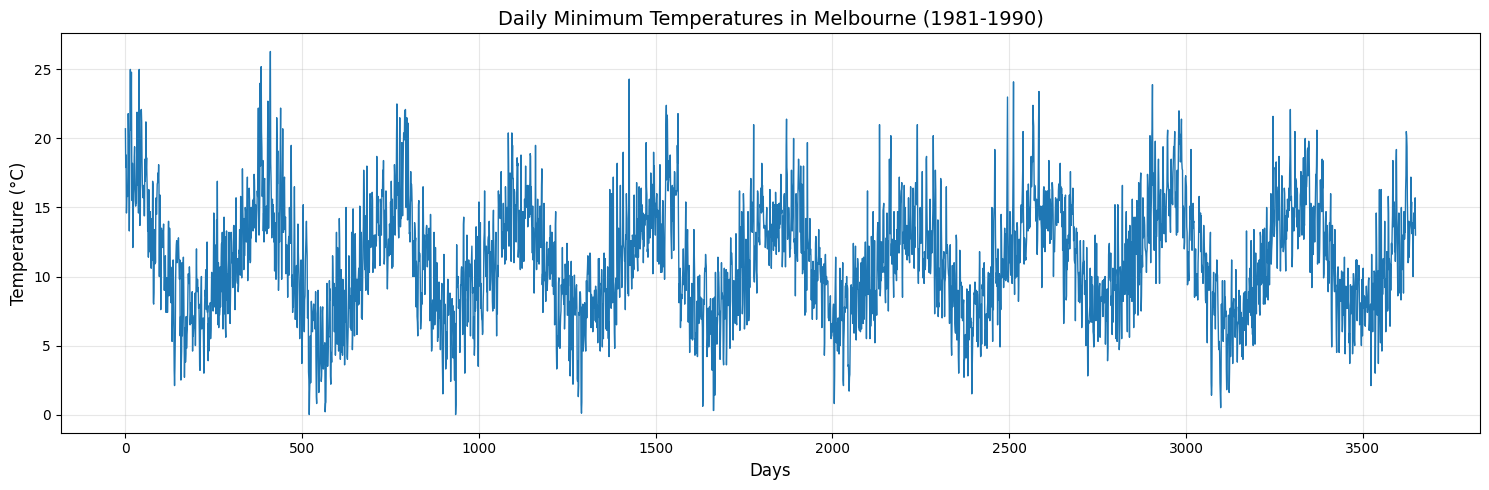

In [ ]:
# Visualize the time series data
plt.figure(figsize=(15, 5))
plt.plot(df['value'], linewidth=1)
plt.title('Daily Minimum Temperatures in Melbourne (1981-1990)', fontsize=14)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Save Dataset to CSV**

In [ ]:
# Save the dataset locally in Colab
df.to_csv('timeseries_data.csv', index=False)
print("Dataset saved as 'timeseries_data.csv'")
print(f"File contains {len(df)} records")

Dataset saved as 'timeseries_data.csv'
File contains 3650 records


**Define Helper Function - create_sequences**

In [ ]:
def create_sequences(data, seq_length):
    """
    Create sequences for LSTM input
    Args:
        data: Input time series data
        seq_length: Length of look-back window
    Returns:
        X: Input sequences
        y: Target values
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

print("create_sequences function defined!")

create_sequences function defined!


**Define Data Preparation Function**

In [ ]:
def prepare_data(filename, seq_length, train_split=0.8):
    """
    Load and preprocess data
    """
    # Load data
    df = pd.read_csv(filename)
    data = df['value'].values.reshape(-1, 1)

    # Normalize data
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    # Create sequences
    X, y = create_sequences(data_scaled, seq_length)

    # Split into train and test sets
    train_size = int(len(X) * train_split)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    return X_train, X_test, y_train, y_test, scaler

print("prepare_data function defined!")

prepare_data function defined!


**Preparing Data**

In [ ]:
# Set sequence length (look-back window)
SEQ_LENGTH = 30  # Use 30 days to predict the next day

# Prepare data
X_train, X_test, y_train, y_test, scaler = prepare_data(
    'timeseries_data.csv',
    seq_length=SEQ_LENGTH,
    train_split=0.8
)

print(f"Training set shape: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Test set shape: X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"\nSequence length: {SEQ_LENGTH}")
print(f"Number of training samples: {len(X_train)}")
print(f"Number of test samples: {len(X_test)}")

Training set shape: X_train: (2896, 30, 1), y_train: (2896, 1)
Test set shape: X_test: (724, 30, 1), y_test: (724, 1)

Sequence length: 30
Number of training samples: 2896
Number of test samples: 724


**Define LSTM Model Building Function**

In [ ]:
def build_lstm_model(seq_length, n_features=1):
    """
    Build LSTM model architecture
    """
    model = Sequential([
        LSTM(50, activation='relu', input_shape=(seq_length, n_features), return_sequences=True),
        LSTM(30, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

print("build_lstm_model function defined!")

build_lstm_model function defined!


**Build Model**

In [ ]:
# Build the model
model = build_lstm_model(seq_length=SEQ_LENGTH, n_features=1)

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,151 (78.71 KB)

 Trainable params: 20,151 (78.71 KB)

 Non-trainable params: 0 (0.00 B)

**Define Training Function**

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=32):
    """
    Train the LSTM model
    """
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=1
    )
    return history

print("train_model function defined!")

train_model function defined!


**Train the Model**

In [ ]:
# Train the model
print("Starting model training...")
history = train_model(
    model,
    X_train, y_train,
    X_test, y_test,
    epochs=70,
    batch_size=32
)
print("\nTraining completed!")

Starting model training...
Epoch 1/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0088 - val_loss: 0.0075
Epoch 2/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0088 - val_loss: 0.0069
Epoch 3/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0089 - val_loss: 0.0076
Epoch 4/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0091 - val_loss: 0.0073
Epoch 5/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0089 - val_loss: 0.0069
Epoch 6/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0087 - val_loss: 0.0075
Epoch 7/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0089 - val_loss: 0.0069
Epoch 8/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0085 - val_loss: 0.0070
Epoch 9/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0090 - val_loss: 0.0069
Epoch 10/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0088 - val_loss: 0.0069
Epoch 11/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0086 - val_loss: 0.0069
Epoch 12/70
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms

**Define Basic Evaluation Function**

In [ ]:
def evaluate_and_visualize(model, X_test, y_test, scaler):
    """
    Make predictions and visualize results
    """
    # Make predictions
    y_pred = model.predict(X_test)

    # Inverse transform predictions and actual values
    y_test_inv = scaler.inverse_transform(y_test)
    y_pred_inv = scaler.inverse_transform(y_pred)

    # Calculate metrics
    mse = np.mean((y_test_inv - y_pred_inv)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test_inv - y_pred_inv))

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_inv, label='Actual', linewidth=2)
    plt.plot(y_pred_inv, label='Predicted', linewidth=2, alpha=0.7)
    plt.legend()
    plt.title(f'RMSE: {rmse:.2f}, MAE: {mae:.2f}')
    plt.xlabel('Time Steps')
    plt.ylabel('Temperature (°C)')
    plt.grid(True, alpha=0.3)
    plt.show()

    return rmse, mae

print("evaluate_and_visualize function defined!")

evaluate_and_visualize function defined!


**Basic Evaluation**

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


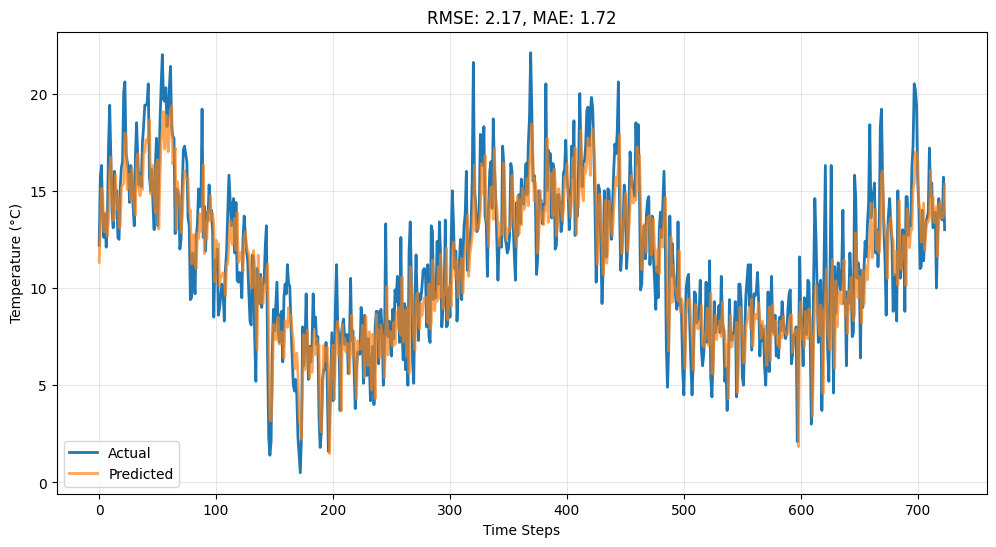


Basic Evaluation Metrics:
RMSE: 2.1738°C
MAE: 1.7200°C


In [ ]:
# Evaluate the model
rmse, mae = evaluate_and_visualize(model, X_test, y_test, scaler)

print(f"\nBasic Evaluation Metrics:")
print(f"RMSE: {rmse:.4f}°C")
print(f"MAE: {mae:.4f}°C")

**Define Enhanced Metrics Calculation Function**

In [ ]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate comprehensive evaluation metrics
    """
    # Basic metrics
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    # Additional metrics
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true))) * 100

    # R-squared
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    # Directional accuracy
    direction_true = np.sign(np.diff(y_true.flatten()))
    direction_pred = np.sign(np.diff(y_pred.flatten()))
    directional_accuracy = np.mean(direction_true == direction_pred) * 100

    return {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'SMAPE': smape,
        'R2': r2,
        'DirectionalAccuracy': directional_accuracy
    }

print("calculate_metrics function defined!")

calculate_metrics function defined!


**Define Advanced Visualization Function**

In [ ]:
def advanced_visualization(y_true, y_pred, history=None):
    """
    Create comprehensive visualization suite
    """
    plt.style.use('seaborn-v0_8-darkgrid')

    # Create subplot grid
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(3, 2)

    # 1. Actual vs Predicted Time Series
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(y_true, label='Actual', linewidth=2)
    ax1.plot(y_pred, label='Predicted', linewidth=2, alpha=0.7)
    ax1.set_title('Time Series Prediction', fontsize=14)
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Temperature (°C)')
    ax1.legend()
    ax1.grid(True)

    # 2. Residual Plot
    ax2 = fig.add_subplot(gs[1, 0])
    residuals = y_true.flatten() - y_pred.flatten()
    ax2.scatter(y_pred, residuals, alpha=0.5)
    ax2.axhline(y=0, color='r', linestyle='--')
    ax2.set_title('Residual Plot', fontsize=14)
    ax2.set_xlabel('Predicted Values')
    ax2.set_ylabel('Residuals')

    # 3. Residual Distribution
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(residuals, bins=30, density=True, alpha=0.7)
    mu, std = stats.norm.fit(residuals)
    xmin, xmax = ax3.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    ax3.plot(x, p, 'k', linewidth=2)
    ax3.set_title('Residual Distribution', fontsize=14)

    # 4. Training History (if available)
    if history is not None:
        ax4 = fig.add_subplot(gs[2, 0])
        ax4.plot(history.history['loss'], label='Training Loss')
        ax4.plot(history.history['val_loss'], label='Validation Loss')
        ax4.set_title('Training History', fontsize=14)
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Loss')
        ax4.legend()

    # 5. Q-Q Plot
    ax5 = fig.add_subplot(gs[2, 1])
    stats.probplot(residuals, dist="norm", plot=ax5)
    ax5.set_title('Q-Q Plot', fontsize=14)

    plt.tight_layout()
    return fig

print("advanced_visualization function defined!")

advanced_visualization function defined!


**Define Comprehensive Evaluation Function**

In [ ]:
def evaluate_forecast(model, X_test, y_test, scaler, history=None):
    """
    Comprehensive evaluation function
    """
    # Generate predictions
    y_pred = model.predict(X_test)

    # Inverse transform predictions and actual values
    y_test_inv = scaler.inverse_transform(y_test)
    y_pred_inv = scaler.inverse_transform(y_pred)

    # Calculate metrics
    metrics = calculate_metrics(y_test_inv, y_pred_inv)

    # Generate visualizations
    fig = advanced_visualization(y_test_inv, y_pred_inv, history)

    # Print metrics report
    print("\nForecast Evaluation Metrics:")
    print("============================")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    return metrics, fig

print("evaluate_forecast function defined!")

evaluate_forecast function defined!


**Run Comprehensive Evaluation**

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Forecast Evaluation Metrics:
RMSE: 2.1738
MAE: 1.7200
MAPE: 19.0774
SMAPE: 17.4314
R2: 0.7189
DirectionalAccuracy: 46.0581


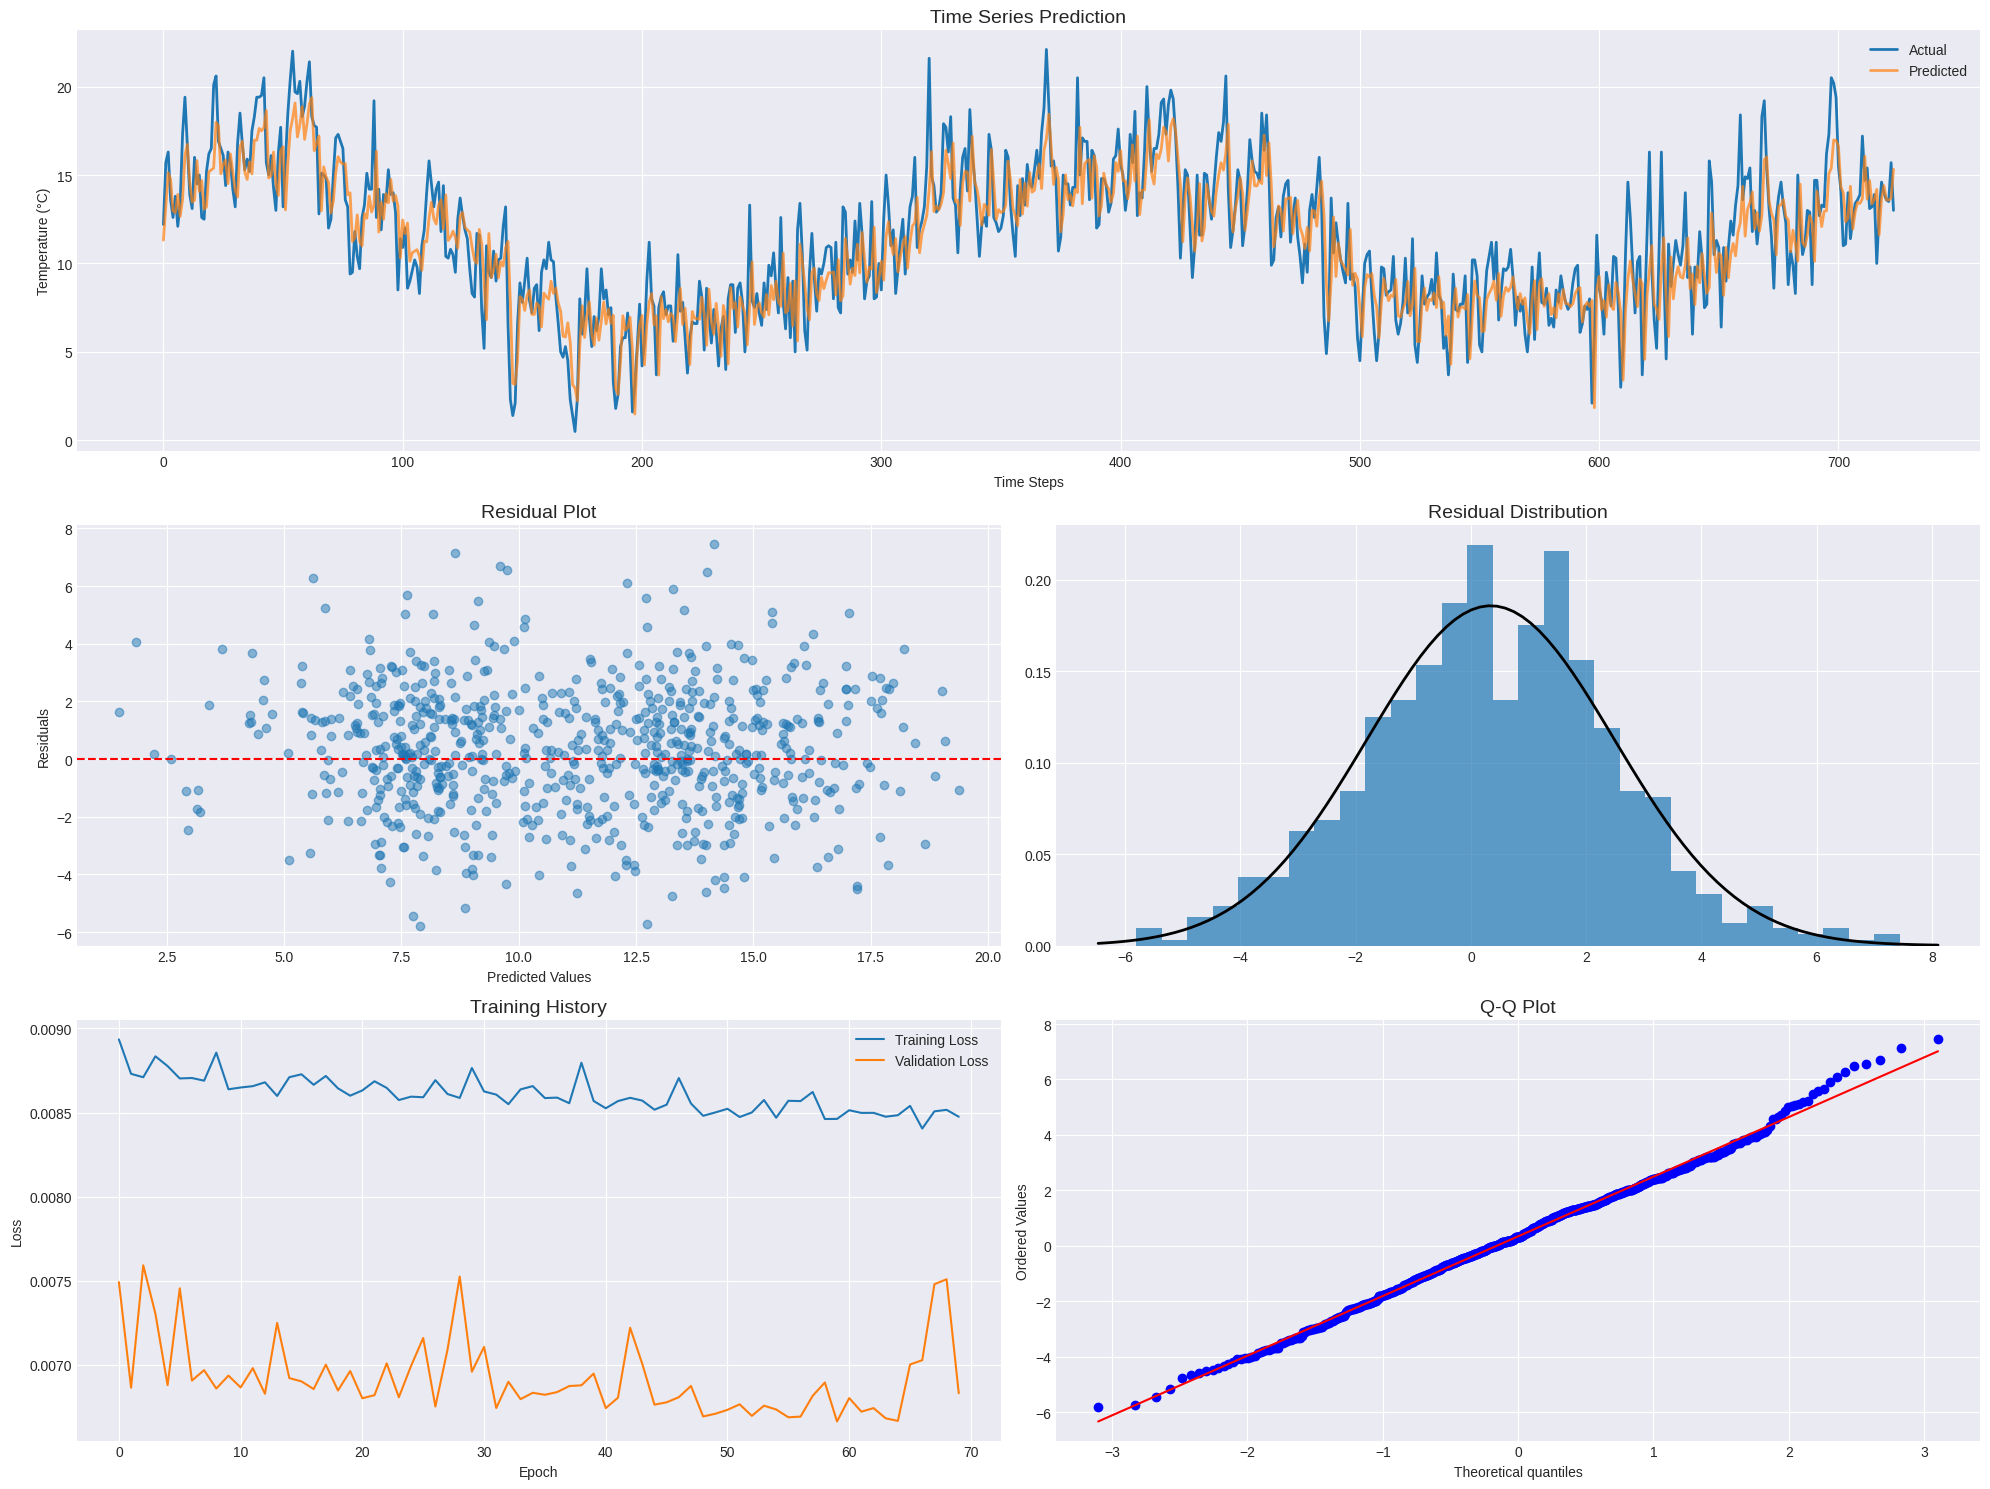

In [ ]:
# Perform comprehensive evaluation
metrics, fig = evaluate_forecast(model, X_test, y_test, scaler, history)
plt.show()

**Define Confidence Intervals Function**

In [ ]:
def forecast_confidence_intervals(model, X_test, scaler, n_samples=100):
    """
    Generate forecast with confidence intervals using Monte Carlo Dropout
    """
    predictions = np.zeros((n_samples, len(X_test)))

    # Enable dropout during inference
    for i in range(n_samples):
        predictions[i, :] = model.predict(X_test, training=True).flatten()

    # Calculate statistics
    mean_prediction = np.mean(predictions, axis=0)
    std_prediction = np.std(predictions, axis=0)

    # Calculate confidence intervals
    lower_bound = mean_prediction - 1.96 * std_prediction
    upper_bound = mean_prediction + 1.96 * std_prediction

    # Inverse transform
    mean_prediction = scaler.inverse_transform(mean_prediction.reshape(-1, 1))
    lower_bound = scaler.inverse_transform(lower_bound.reshape(-1, 1))
    upper_bound = scaler.inverse_transform(upper_bound.reshape(-1, 1))

    return mean_prediction, lower_bound, upper_bound

print("forecast_confidence_intervals function defined!")

forecast_confidence_intervals function defined!


**Define Time Series Cross-Validation Function**

In [ ]:
def time_series_cv(data, n_splits, seq_length):
    """
    Implement time series cross-validation
    """
    splits = []
    split_size = len(data) // (n_splits + 1)

    for i in range(n_splits):
        train_start = 0
        train_end = split_size * (i + 1)
        test_end = train_end + split_size

        if test_end > len(data):
            test_end = len(data)

        train_data = data[train_start:train_end]
        test_data = data[train_end:test_end]

        # Create sequences
        X_train, y_train = create_sequences(train_data, seq_length)
        X_test, y_test = create_sequences(test_data, seq_length)

        splits.append((X_train, y_train, X_test, y_test))

    return splits

print("time_series_cv function defined!")

time_series_cv function defined!


**Run Cross-Validation**

In [ ]:
# Load and prepare data for cross-validation
df_cv = pd.read_csv('timeseries_data.csv')
data_cv = df_cv['value'].values.reshape(-1, 1)

# Normalize
scaler_cv = MinMaxScaler()
data_scaled_cv = scaler_cv.fit_transform(data_cv)

# Perform cross-validation
n_splits = 3
cv_splits = time_series_cv(data_scaled_cv, n_splits, SEQ_LENGTH)

print(f"Created {n_splits} cross-validation splits")
for i, (X_tr, y_tr, X_te, y_te) in enumerate(cv_splits):
    print(f"Split {i+1}: Train size={len(X_tr)}, Test size={len(X_te)}")

Created 3 cross-validation splits
Split 1: Train size=882, Test size=882
Split 2: Train size=1794, Test size=882
Split 3: Train size=2706, Test size=882


**Train Model on Each Cross-Validation Split**

In [ ]:
# Train and evaluate on each CV split
cv_results = []

for i, (X_tr, y_tr, X_te, y_te) in enumerate(cv_splits):
    print(f"\n{'='*50}")
    print(f"Training on CV Split {i+1}/{n_splits}")
    print(f"{'='*50}")

    # Build new model
    cv_model = build_lstm_model(seq_length=SEQ_LENGTH, n_features=1)

    # Train
    cv_history = train_model(cv_model, X_tr, y_tr, X_te, y_te, epochs=30, batch_size=32)

    # Evaluate
    y_pred_cv = cv_model.predict(X_te)
    y_te_inv = scaler_cv.inverse_transform(y_te)
    y_pred_inv = scaler_cv.inverse_transform(y_pred_cv)

    # Calculate metrics
    metrics_cv = calculate_metrics(y_te_inv, y_pred_inv)
    cv_results.append(metrics_cv)

    print(f"\nSplit {i+1} Results:")
    for metric, value in metrics_cv.items():
        print(f"  {metric}: {value:.4f}")

# Average results
print(f"\n{'='*50}")
print("Average Cross-Validation Results:")
print(f"{'='*50}")
for key in cv_results[0].keys():
    avg_value = np.mean([result[key] for result in cv_results])
    std_value = np.std([result[key] for result in cv_results])
    print(f"{key}: {avg_value:.4f} ± {std_value:.4f}")


Training on CV Split 1/3
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.1612 - val_loss: 0.0130
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0173 - val_loss: 0.0125
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0143 - val_loss: 0.0122
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0129 - val_loss: 0.0114
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0129 - val_loss: 0.0118
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0124 - val_loss: 0.0113
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0133 - val_loss: 0.0124
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0134 - val_loss: 0.0113
Epoch 9/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0126 - val_loss: 0.0112
Epoch 10/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0124 - val_loss: 0.0114
Epoch 11/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0125 - val_loss: 0.0110
Epoch 12/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0126 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.1061 - val_loss: 0.0131
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0135 - val_loss: 0.0113
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0124 - val_loss: 0.0119
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0126 - val_loss: 0.0112
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0118 - val_loss: 0.0112
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0126 - val_loss: 0.0111
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0122 - val_loss: 0.0110
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0126 - val_loss: 0.0110
Epoch 9/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0122 - val_loss: 0.0116
Epoch 10/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0118 - val_loss: 0.0117
Epoch 11/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0125 - val_loss: 0.0118
Epoch 12/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0124 - val_loss: 0.011

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 0.0897 - val_loss: 0.0111
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0122 - val_loss: 0.0105
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0125 - val_loss: 0.0108
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0124 - val_loss: 0.0104
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0115 - val_loss: 0.0107
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0124 - val_loss: 0.0102
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0113 - val_loss: 0.0102
Epoch 8/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0114 - val_loss: 0.0101
Epoch 9/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0122 - val_loss: 0.0101
Epoch 10/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0119 - val_loss: 0.0115
Epoch 11/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0119 - val_loss: 0.0099
Epoch 12/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0106 - val_loss: 0.0099